In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from dataset_load import DatasetCreator

In [2]:
!pwd

/home/student/work/3d_Generative/model/dataset


## Необходимые переменные и загрузка с чекпоинта

In [3]:
data_root_dir = Path('./data')
modelnet_dir = Path('./modelNet')
dataset = modelnet_dir / 'ModelNet10'
dataset_dir = Path('./dataset')

In [4]:
sample_size = 10

data_sheet = pd.read_csv(modelnet_dir / 'metadata_modelnet10.csv')
data_sheet = data_sheet[data_sheet['class'] != '.DS']

data_done = pd.read_csv('modelnet_converted.csv')

data_sheet = pd.concat([data_sheet, data_done])
data_sheet = data_sheet.drop_duplicates(subset=['object_id'], keep=False)
data_sheet = data_sheet.groupby(['class']).sample(n=sample_size)
data_sheet = data_sheet.reset_index(drop=True)

diff_table = (data_sheet.groupby('class')['class'].count() - data_done.groupby('class')['class'].count()).map(lambda x: sample_size - max(0, x), na_action='ignore').fillna(0).astype(int)

drop_list = []
for i, _class in enumerate(data_sheet['class'].unique()):
    drop_list += list(range(i * sample_size, i*sample_size + diff_table.iloc[i]))

data_sheet = data_sheet.drop(drop_list)
data_sheet = data_sheet.reset_index(drop=True)

print(f"Estimated time to calculate: {(data_sheet.groupby('class')['object_id'].count().sum() * 15) // 60}h {(data_sheet.groupby('class')['object_id'].count().sum() * 15) % 60}min")
data_sheet

Estimated time to calculate: 1h 45min


,object_id,class,split,object_path,color_path,density_path
0,table_0027,table,train,table/train/table_0027.off,NaN,NaN
1,table_0420,table,test,table/test/table_0420.off,NaN,NaN
2,toilet_0015,toilet,train,toilet/train/toilet_0015.off,NaN,NaN
3,toilet_0162,toilet,train,toilet/train/toilet_0162.off,NaN,NaN
4,toilet_0234,toilet,train,toilet/train/toilet_0234.off,NaN,NaN
5,toilet_0216,toilet,train,toilet/train/toilet_0216.off,NaN,NaN
6,toilet_0268,toilet,train,toilet/train/toilet_0268.off,NaN,NaN


## Непоследственно код по превращению в триплейны
довольно просто, правда?)

In [5]:
dataloader = DatasetCreator(volume_size = 256, render_size = 256)

In [6]:
for index, row in data_sheet.iterrows():
    dataloader.create_triplane(data_dir=dataset, dataset_dir=dataset_dir, object_name=row.object_path, csv_save_file='modelnet_converted.csv')

6286it [23:59,  4.37it/s]                          


KeyboardInterrupt: 

 97%|█████████▋| 2920/3000 [12:09<00:19,  4.00it/s]


Final Loss: 0.019700802862644196


100%|█████████▉| 2994/3000 [11:54<00:01,  4.19it/s]


Final Loss: 0.019956808537244797


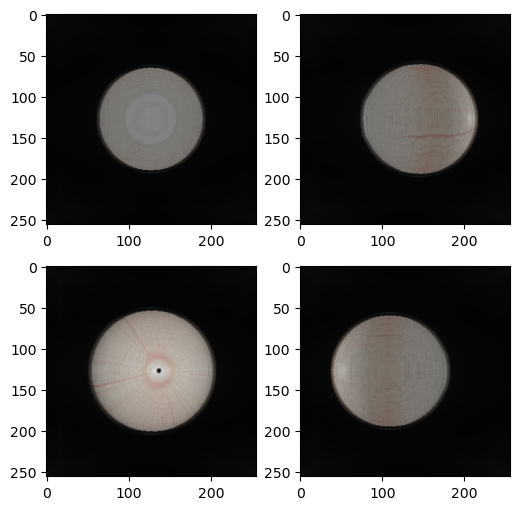

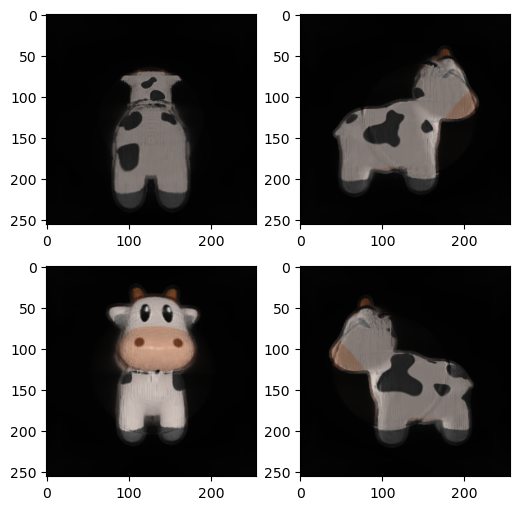

In [4]:
for data_dir in dataset_dirs_list:
    result = dataloader.create_triplane(data_dir=data_root_dir / data_dir, dataset_dir=dataset_dir)

In [94]:
sample_size = 5
data_sheet = pd.read_csv(modelnet_dir / 'metadata_modelnet10.csv')
data_sheet = data_sheet[data_sheet['class'] != '.DS']
data_sheet = data_sheet.groupby(['class']).sample(n=5, replace=True)
data_sheet = data_sheet.reset_index(drop=True)

data_done = pd.read_csv('modelnet_converted.csv')
diff_table = (data_sheet.groupby('class')['class'].count() - data_done.groupby('class')['class'].count()).map(lambda x: 5 - max(0, x), na_action='ignore').fillna(0).astype(int)

drop_list = []
for i, _class in enumerate(data_sheet['class'].unique()):
    drop_list += list(range(i * sample_size, i*sample_size + diff_table.iloc[i]))

print(drop_list)
data_sheet = data_sheet.drop(drop_list)
data_sheet

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


,object_id,class,split,object_path
30,night_stand_0242,night,test,night/test/night_stand_0242.off
31,night_stand_0083,night,train,night/train/night_stand_0083.off
32,night_stand_0043,night,train,night/train/night_stand_0043.off
33,night_stand_0035,night,train,night/train/night_stand_0035.off
34,night_stand_0215,night,test,night/test/night_stand_0215.off
35,sofa_0535,sofa,train,sofa/train/sofa_0535.off
36,sofa_0256,sofa,train,sofa/train/sofa_0256.off
37,sofa_0602,sofa,train,sofa/train/sofa_0602.off
38,sofa_0575,sofa,train,sofa/train/sofa_0575.off
39,sofa_0056,sofa,train,sofa/train/sofa_0056.off
